In [51]:
## import to train and test autoencoder for anamoly detection on normal dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import Dense
import os

sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize']=(10,5) ## trying to set the default plot size

#reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [52]:
## now loading the preprocessed data
X_train = np.load('../data/processed/X_train.npy')
X_test  = np.load('../data/processed/X_test.npy')
y_train = np.load('../data/processed/y_train.npy')
y_test  = np.load('../data/processed/y_test.npy')
X_train_normal = np.load('../data/processed/X_train_normal.npy')

print(f"X_train:        {X_train.shape}")
print(f"X_test:         {X_test.shape}")
print(f"X_train_normal: {X_train_normal.shape}")
n_features = X_train_normal.shape[1]
print(f"n_features:     {n_features}")


X_train:        (125973, 122)
X_test:         (22251, 122)
X_train_normal: (67343, 122)
n_features:     122


In [53]:
## definfing the model architecture
autoencoder=keras.Sequential([
    layers.Input(shape=(n_features,)),
    # encoder — compresses 122 features down to a bottleneck
   ##Dense(64,activation='relu',name='add1'),
    Dense(32,activation='relu',name='layer1'),
    Dense(16,activation='relu',name='layer2'),
    Dense(8,activation='relu',name='bottleneck'),
    # decoder — mirrors the encoder, reconstructs back to 122
    Dense(16,activation='relu',name='layer4'),
    Dense(32,activation='relu',name='layer5'),
   ## Dense(64,activation='relu',name='add2'),
    Dense(n_features,activation='sigmoid',name='layer6')
])

autoencoder.compile(optimizer='adam',loss='mse')
autoencoder.summary()


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layer1 (Dense)                  │ (None, 32)             │         3,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer2 (Dense)                  │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer4 (Dense)                  │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer5 (Dense)                  │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer6 (Dense)                  │ (None, 122)            │         4,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,314 (36.38 KB)

 Trainable params: 9,314 (36.38 KB)

 Non-trainable params: 0 (0.00 B)

In [54]:
history = autoencoder.fit(
    X_train_normal, X_train_normal,   # input == target — this is what makes it an autoencoder
    epochs=50,
    batch_size=256,
    validation_split=0.2,
    shuffle=True,
    verbose=1
)

Epoch 1/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0580 - val_loss: 0.0165
Epoch 2/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0126 - val_loss: 0.0095
Epoch 3/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0077 - val_loss: 0.0061
Epoch 4/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0055 - val_loss: 0.0048
Epoch 5/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0043 - val_loss: 0.0039
Epoch 6/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0036 - val_loss: 0.0034
Epoch 7/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 987us/step - loss: 0.0033 - val_loss: 0.0032
Epoch 8/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 995us/step - loss: 0.0031 - val_loss: 0.0030
Epoch 9/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 993us/step - loss: 0.0030 - val_loss: 0.0029
Epoch 10/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 990us/step - loss: 0.0028 - val_loss: 0.0027
Epoch 11/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 993us/step - loss: 0.0026 - val_loss: 0.0025
Epoch 12/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0

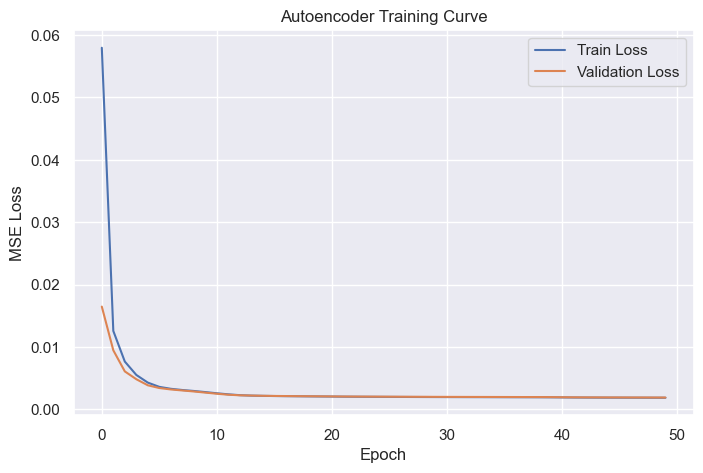

In [55]:
## ploting the figure to see the how mse loss and val_loss decreases
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Autoencoder Training Curve')
plt.legend()
plt.show()

In [58]:
## reconstruction error on normal training data — used to set threshold tau
reconstructions_normal = autoencoder.predict(X_train_normal, batch_size=256, verbose=0)

# per-sample MSE: mean squared error across all 122 features, for each row
recon_error_normal = np.mean(np.square(X_train_normal - reconstructions_normal), axis=1)

print(f"recon_error_normal shape: {recon_error_normal.shape}")
print(f"min:    {recon_error_normal.min():.6f}")
print(f"mean:   {recon_error_normal.mean():.6f}")
print(f"median: {np.median(recon_error_normal):.6f}")
print(f"max:    {recon_error_normal.max():.6f}")

recon_error_normal shape: (67343,)
min:    0.000000
mean:   0.001871
median: 0.000048
max:    0.082045


this is a good sign cause our autoencoder must produce less reconstruction error for normal data only 

That distribution tells us something important: median (0.000048) is ~40x smaller than the mean (0.001871), with a long right tail up to 0.082. This is classic heavy right-skew — most normal traffic reconstructs almost perfectly, but a minority of "harder" normal samples pull the mean up.

Threshold (tau) at 97th percentile: 0.016462
% of normal train samples above tau: 3.00%


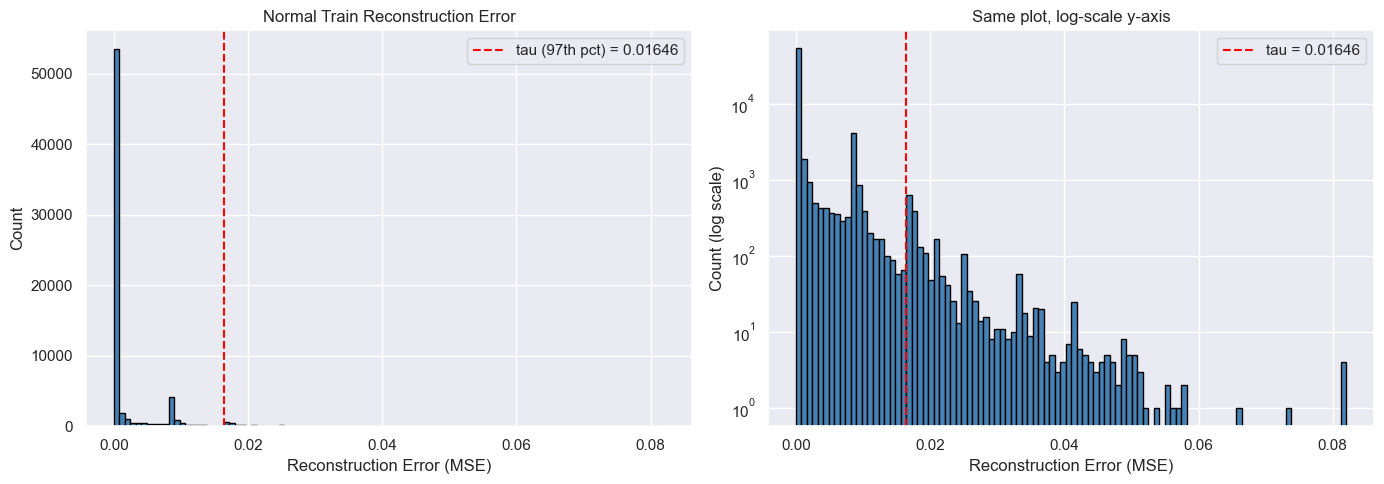

In [59]:
## setting threshold tau using percentile of normal reconstruction error
percentile = 97  # tune this — 95/97/99 are common starting points
tau = np.percentile(recon_error_normal, percentile)
print(f"Threshold (tau) at {percentile}th percentile: {tau:.6f}")

# how many normal samples would be (falsely) flagged at this tau?
false_flag_rate = np.mean(recon_error_normal > tau) * 100
print(f"% of normal train samples above tau: {false_flag_rate:.2f}%")

## visualizing the distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(recon_error_normal, bins=100, color='steelblue', edgecolor='black')
axes[0].axvline(tau, color='red', linestyle='--', label=f'tau ({percentile}th pct) = {tau:.5f}')
axes[0].set_xlabel('Reconstruction Error (MSE)')
axes[0].set_ylabel('Count')
axes[0].set_title('Normal Train Reconstruction Error')
axes[0].legend()

axes[1].hist(recon_error_normal, bins=100, color='steelblue', edgecolor='black')
axes[1].axvline(tau, color='red', linestyle='--', label=f'tau = {tau:.5f}')
axes[1].set_yscale('log')
axes[1].set_xlabel('Reconstruction Error (MSE)')
axes[1].set_ylabel('Count (log scale)')
axes[1].set_title('Same plot, log-scale y-axis')
axes[1].legend()

plt.tight_layout()
plt.show()

In [60]:
## reconstruction error on FULL train and test sets (all 5 classes, not just normal)
recon_train_full = autoencoder.predict(X_train, batch_size=256, verbose=0)
recon_test_full  = autoencoder.predict(X_test, batch_size=256, verbose=0)

recon_error_train = np.mean(np.square(X_train - recon_train_full), axis=1)
recon_error_test  = np.mean(np.square(X_test - recon_test_full), axis=1)

print(f"recon_error_train shape: {recon_error_train.shape}")
print(f"recon_error_test shape:  {recon_error_test.shape}")

print(f"\nTrain — mean: {recon_error_train.mean():.6f}, median: {np.median(recon_error_train):.6f}")
print(f"Test  — mean: {recon_error_test.mean():.6f}, median: {np.median(recon_error_test):.6f}")

recon_error_train shape: (125973,)
recon_error_test shape:  (22251,)

Train — mean: 0.025849, median: 0.008338
Test  — mean: 0.020921, median: 0.010150


In [61]:
## checking label format before plotting by class
print("y_train dtype:", y_train.dtype)
print("y_train unique values:", np.unique(y_train))
print("y_test unique values:", np.unique(y_test))

y_train dtype: int64
y_train unique values: [0 1 2 3 4]
y_test unique values: [0 1 2 3 4]


--- TRAIN ---
Normal   (n= 67343): mean=0.001871, median=0.000048
DoS      (n= 45927): mean=0.060500, median=0.068639
Probe    (n= 11656): mean=0.029380, median=0.019904
R2L      (n=   995): mean=0.008531, median=0.000521
U2R      (n=    52): mean=0.013871, median=0.014639

--- TEST ---
Normal   (n=  9711): mean=0.002200, median=0.000034
DoS      (n=  7167): mean=0.043775, median=0.046998
Probe    (n=  2421): mean=0.041106, median=0.041462
R2L      (n=  2885): mean=0.010359, median=0.010942
U2R      (n=    67): mean=0.015158, median=0.016534



/var/folders/07/zkvtwz216_q7kwpfdzr_bj6m0000gn/T/ipykernel_1717/2098975225.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=list(label_map.values()), showfliers=False)
/var/folders/07/zkvtwz216_q7kwpfdzr_bj6m0000gn/T/ipykernel_1717/2098975225.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=list(label_map.values()), showfliers=False)


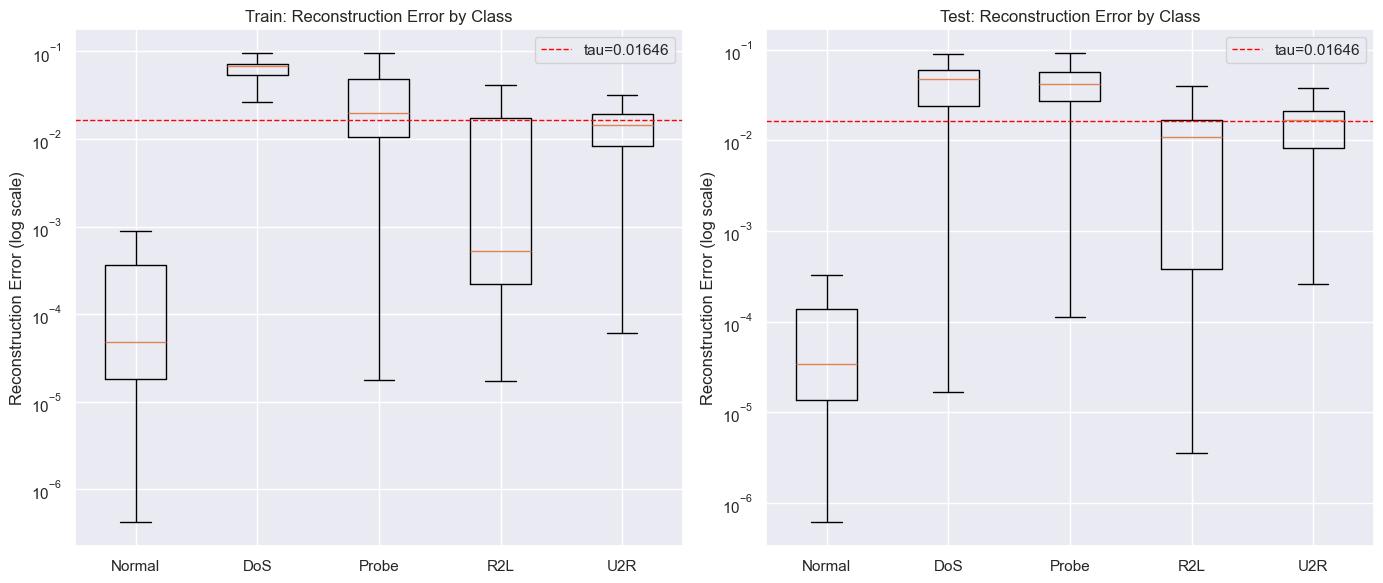

In [63]:
## reconstruction error by class — using confirmed mapping from notebook 02
label_map = {0: 'Normal', 1: 'DoS', 2: 'Probe', 3: 'R2L', 4: 'U2R'}

def error_summary_by_class(recon_error, y, dataset_name):
    print(f"--- {dataset_name} ---")
    for class_id, class_name in label_map.items():
        mask = (y == class_id)
        errs = recon_error[mask]
        print(f"{class_name:8s} (n={mask.sum():6d}): mean={errs.mean():.6f}, median={np.median(errs):.6f}")
    print()

error_summary_by_class(recon_error_train, y_train, "TRAIN")
error_summary_by_class(recon_error_test, y_test, "TEST")

## boxplot — reconstruction error distribution per class, log scale to handle skew
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, recon_error, y, title in [
    (axes[0], recon_error_train, y_train, "Train"),
    (axes[1], recon_error_test, y_test, "Test")
]:
    data = [recon_error[y == cid] for cid in label_map]
    ax.boxplot(data, labels=list(label_map.values()), showfliers=False)
    ax.set_yscale('log')
    ax.set_ylabel('Reconstruction Error (log scale)')
    ax.set_title(f'{title}: Reconstruction Error by Class')
    ax.axhline(tau, color='red', linestyle='--', linewidth=1, label=f'tau={tau:.5f}')
    ax.legend()

plt.tight_layout()
plt.show()

In [64]:
## saving all artifacts from notebook 03
import os

os.makedirs('../models', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)

# 1. the trained autoencoder itself
autoencoder.save('../models/autoencoder.keras')

# 2. threshold tau — plain text, simple to read back later
with open('../models/threshold.txt', 'w') as f:
    f.write(str(tau))

# 3. reconstruction error arrays — these become feature 42 in notebook 04
np.save('../data/processed/recon_error_train.npy', recon_error_train)
np.save('../data/processed/recon_error_test.npy', recon_error_test)

print("Saved:")
print("  models/autoencoder.keras")
print(f"  models/threshold.txt (tau = {tau:.6f})")
print(f"  data/processed/recon_error_train.npy {recon_error_train.shape}")
print(f"  data/processed/recon_error_test.npy  {recon_error_test.shape}")

Saved:
  models/autoencoder.keras
  models/threshold.txt (tau = 0.016462)
  data/processed/recon_error_train.npy (125973,)
  data/processed/recon_error_test.npy  (22251,)
